# Pedestrian access to the subway: Upper West Side vs. Red Hook

**Research question:** How does pedestrian-network structure affect access to rapid transit in the Upper West Side and Red Hook, and how accurately does Euclidean distance represent that access?

**Working hypothesis:** Upper West Side origins will generally have shorter walking distances to subway entrances. Red Hook may show both longer distances and larger network penalties limited connections constrain pedestrian movement.

Scope: this measures pedestrian access to subway entrances, not overall transportation access. Bus and ferry service, frequency, reliability, affordability, safety, and accessibility are outside the current analysis


## Setup

This notebook is configured to use the Anaconda `cdp` kernel


In [1]:
# %pip install -q osmnx geopandas pandas numpy matplotlib seaborn requests

from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
import requests
import seaborn as sns
from shapely.geometry import LineString, Point

warnings.filterwarnings("ignore", category=UserWarning)

ox.settings.use_cache = True
ox.settings.log_console = False
sns.set_theme(style="whitegrid")

RANDOM_SEED = 42
SAMPLE_SIZE = 150
STUDY_RADIUS_M = 1_500       # equal-radius comparison area around each center
NETWORK_BUFFER_M = 3_000
WALKING_SPEED_M_PER_MIN = 80  # approximately 4.8 km/h
PROJECT_CRS = "EPSG:6539"      # NAD83(2011) / New York Long Island (meters)

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

PLACES = {
    "Upper West Side": "Upper West Side, Manhattan, New York City, New York, USA",
    "Red Hook": "Red Hook, Brooklyn, New York City, New York, USA",
}


## Define comparable neighborhood study areas

OpenStreetMap's geocoder recognizes Upper West Side and Red Hook as points, not polygons


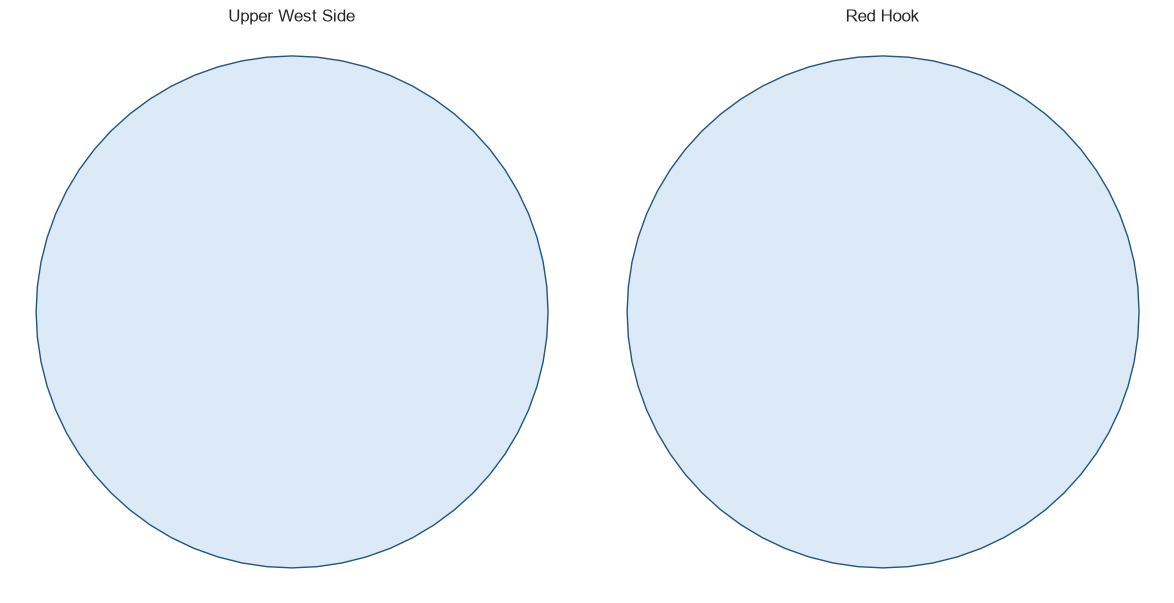

In [2]:
def load_boundary(place_query, radius_m=STUDY_RADIUS_M):
    # ox.geocode returns (latitude, longitude) for these informal neighborhoods.
    latitude, longitude = ox.geocode(place_query)
    center = gpd.GeoSeries(
        [Point(longitude, latitude)],
        crs=4326,
    ).to_crs(PROJECT_CRS)
    return gpd.GeoDataFrame(
        {"display_name": [place_query]},
        geometry=center.buffer(radius_m),
        crs=PROJECT_CRS,
    )


boundaries = {
    neighborhood: load_boundary(query)
    for neighborhood, query in PLACES.items()
}

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (neighborhood, boundary) in zip(axes, boundaries.items()):
    boundary.plot(ax=ax, facecolor="#dceaf7", edgecolor="#24557a")
    ax.set_title(neighborhood)
    ax.set_axis_off()
plt.tight_layout()


## Download walkable street networks

OSMnx represents intersections and dead ends as nodes and walkable street segments as edges


In [3]:
def download_walk_network(boundary_projected, buffer_m=NETWORK_BUFFER_M):
    buffered = boundary_projected.geometry.iloc[0].buffer(buffer_m)
    polygon_wgs84 = gpd.GeoSeries([buffered], crs=PROJECT_CRS).to_crs(4326).iloc[0]

    graph = ox.graph.graph_from_polygon(
        polygon_wgs84,
        network_type="walk",
        simplify=True,
        retain_all=False,
    )
    return ox.projection.project_graph(graph, to_crs=PROJECT_CRS)


graphs = {
    neighborhood: download_walk_network(boundary)
    for neighborhood, boundary in boundaries.items()
}

for neighborhood, graph in graphs.items():
    print(
        neighborhood,
        f"{len(graph.nodes):,} nodes",
        f"{len(graph.edges):,} edges",
    )


Upper West Side 1,938 nodes 6,152 edges
Red Hook 1,313 nodes 4,052 edges


## Load MTA subway entrances

Dataset page: https://data.ny.gov/Transportation/MTA-Subway-Entrances-and-Exits-2024/i9wp-a4ja


In [4]:
MTA_API_URL = "https://data.ny.gov/resource/i9wp-a4ja.json"
MTA_CACHE = DATA_DIR / "mta_subway_entrances_2024.csv"


def load_subway_entrances():
    if MTA_CACHE.exists():
        df = pd.read_csv(MTA_CACHE)
    else:
        response = requests.get(
            MTA_API_URL,
            params={"$limit": 5000},
            timeout=60,
        )
        response.raise_for_status()
        df = pd.DataFrame(response.json())
        df.to_csv(MTA_CACHE, index=False)

    # Show columns so schema changes are easy to diagnose
    print("MTA columns:", sorted(df.columns.tolist()))

    lat_col = next(c for c in ["entrance_latitude", "latitude"] if c in df.columns)
    lon_col = next(c for c in ["entrance_longitude", "longitude"] if c in df.columns)

    if "entry_allowed" in df.columns:
        df = df[df["entry_allowed"].astype(str).str.lower().eq("yes")].copy()

    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df = df.dropna(subset=[lat_col, lon_col]).copy()
    df["entrance_id"] = np.arange(len(df))

    entrances = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs=4326,
    ).to_crs(PROJECT_CRS)

    keep = [
        c for c in
        ["entrance_id", "stop_name", "complex_id", "daytime_routes", "entrance_type", "geometry"]
        if c in entrances.columns
    ]
    return entrances[keep]


entrances = load_subway_entrances()
entrances.head()


MTA columns: ['borough', 'complex_id', 'constituent_station_name', 'daytime_routes', 'division', 'entrance_georeference', 'entrance_latitude', 'entrance_longitude', 'entrance_type', 'entry_allowed', 'exit_allowed', 'gtfs_stop_id', 'line', 'station_id', 'stop_name']


,entrance_id,stop_name,complex_id,daytime_routes,entrance_type,geometry
0,0,Atlantic Av-Barclays Ctr,617,2 3 4 5 B D N Q R,Stair,POINT (990107.862 188442.164)
1,1,Atlantic Av-Barclays Ctr,617,2 3 4 5 B D N Q R,Elevator,POINT (990216.591 188405.758)
2,2,Atlantic Av-Barclays Ctr,617,2 3 4 5 B D N Q R,Stair,POINT (990237.382 188450.575)
3,3,Union St,28,R,Stair,POINT (988846.229 185982.454)
4,4,Union St,28,R,Stair,POINT (988872.07 186033.975)


## Select comparable origins

Sample the same number of simplified street-network nodes within each neighborhood


In [5]:
def sample_origin_nodes(graph, boundary_projected, sample_size=SAMPLE_SIZE, seed=RANDOM_SEED):
    nodes = ox.convert.graph_to_gdfs(graph, edges=False)
    inside = gpd.sjoin(
        nodes,
        boundary_projected[["geometry"]],
        how="inner",
        predicate="within",
    ).drop(columns=["index_right"])

    n = min(sample_size, len(inside))
    sampled = inside.sample(n=n, random_state=seed).copy()
    sampled["origin_node"] = sampled.index
    return sampled.reset_index(drop=True)


origins = {
    neighborhood: sample_origin_nodes(graphs[neighborhood], boundary)
    for neighborhood, boundary in boundaries.items()
}

for neighborhood, points in origins.items():
    print(neighborhood, len(points), "sampled origins")


Upper West Side 150 sampled origins
Red Hook 150 sampled origins


## Calculate network and Euclidean distance

For each neighborhood:

- subway entrances are snapped to the walk network;
- Euclidean distance is calculated to that **same entrance**, making the comparison valid;
- the entrance-to-network snap offset is added to the route distance; and
- circuity is network distance divided by Euclidean distance.

The route itself does not model crossing delay, slope, construction, perceived safety, or inaccessible entrances.


In [6]:
def analyze_access(neighborhood, graph, origin_points, all_entrances):
    nodes = ox.convert.graph_to_gdfs(graph, edges=False)
    edges = ox.convert.graph_to_gdfs(graph, nodes=False)

    # Restrict entrances to the buffered graph extent.
    graph_area = gpd.GeoDataFrame(
        geometry=[edges.geometry.union_all().convex_hull],
        crs=edges.crs,
    )
    nearby = gpd.sjoin(
        all_entrances,
        graph_area,
        how="inner",
        predicate="intersects",
    ).drop(columns=["index_right"]).copy()

    # Snap each entrance to a walk-network node and retain snap offset.
    nearby["station_node"], nearby["station_snap_m"] = ox.distance.nearest_nodes(
        graph,
        X=nearby.geometry.x.to_numpy(),
        Y=nearby.geometry.y.to_numpy(),
        return_dist=True,
    )

    # Multiple entrances can snap to one node. Keep the closest representative.
    representatives = (
        nearby.sort_values("station_snap_m")
        .drop_duplicates("station_node")
        .set_index("station_node", drop=False)
    )
    station_nodes = representatives.index.tolist()

    distances, paths = nx.multi_source_dijkstra(
        graph,
        sources=station_nodes,
        weight="length",
    )

    records = []
    route_lookup = {}

    for _, origin in origin_points.iterrows():
        origin_node = origin["origin_node"]
        if origin_node not in distances:
            continue

        station_to_origin = paths[origin_node]
        station_node = station_to_origin[0]
        route = list(reversed(station_to_origin))
        station = representatives.loc[station_node]

        euclidean_m = origin.geometry.distance(station.geometry)
        network_m = distances[origin_node] + float(station["station_snap_m"])

        record = {
            "neighborhood": neighborhood,
            "origin_node": origin_node,
            "station_node": station_node,
            "entrance_id": station.get("entrance_id", np.nan),
            "stop_name": station.get("stop_name", "Unknown"),
            "euclidean_m": euclidean_m,
            "network_m": network_m,
            "network_penalty_m": network_m - euclidean_m,
            "circuity_ratio": network_m / euclidean_m if euclidean_m > 0 else np.nan,
            "walking_min": network_m / WALKING_SPEED_M_PER_MIN,
            "geometry": origin.geometry,
            "destination_geometry": station.geometry,
        }
        records.append(record)
        route_lookup[origin_node] = route

    results = gpd.GeoDataFrame(records, geometry="geometry", crs=PROJECT_CRS)
    return results, nearby, route_lookup


analyses = {}
for neighborhood in PLACES:
    analyses[neighborhood] = analyze_access(
        neighborhood,
        graphs[neighborhood],
        origins[neighborhood],
        entrances,
    )

results = pd.concat(
    [analyses[name][0] for name in PLACES],
    ignore_index=True,
)
results = gpd.GeoDataFrame(results, geometry="geometry", crs=PROJECT_CRS)
results.head()


,neighborhood,origin_node,station_node,entrance_id,stop_name,euclidean_m,network_m,network_penalty_m,circuity_ratio,walking_min,geometry,destination_geometry
0,Upper West Side,7182045940,11655743699,619,86 St,780.737852,274.881332,-505.856519,0.352079,3.436017,POINT (990268.768 225822.944),POINT (990647.9142994852 226505.439553245)
1,Upper West Side,11655743726,11777693975,290,86 St,934.930583,418.918209,-516.012374,0.448074,5.236478,POINT (991735.657 225341.12),POINT (992670.5293255994 225351.51860148832)
2,Upper West Side,11548264837,11454574515,621,86 St,514.921122,185.843607,-329.077514,0.360917,2.323045,POINT (991258.675 226502.912),POINT (990804.8313739004 226746.16071009584)
3,Upper West Side,8699249521,11454574515,621,86 St,771.127598,357.248325,-413.879273,0.463280,4.465604,POINT (991533.141 226999.544),POINT (990804.8313739004 226746.16071009584)
4,Upper West Side,11454490713,11655743699,619,86 St,489.343369,185.994858,-303.348511,0.380091,2.324936,POINT (990415.167 226074.991),POINT (990647.9142994852 226505.439553245)


## Summary statistics

Compare medians as well as means to check for skew


In [8]:
summary = (
    results.groupby("neighborhood")
    .agg(
        origins=("origin_node", "count"),
        median_euclidean_m=("euclidean_m", "median"),
        median_network_m=("network_m", "median"),
        mean_network_m=("network_m", "mean"),
        median_penalty_m=("network_penalty_m", "median"),
        median_circuity=("circuity_ratio", "median"),
        median_walk_min=("walking_min", "median"),
        within_10_min=("walking_min", lambda s: (s <= 10).mean()),
        within_15_min=("walking_min", lambda s: (s <= 15).mean()),
    )
    .round(2)
)

summary[["within_10_min", "within_15_min"]] *= 100
summary.rename(
    columns={
        "within_10_min": "within_10_min_pct",
        "within_15_min": "within_15_min_pct",
    },
    inplace=True,
)
summary


,origins,median_euclidean_m,median_network_m,mean_network_m,median_penalty_m,median_circuity,median_walk_min,within_10_min_pct,within_15_min_pct
neighborhood,,,,,,,,,
Red Hook,150,3653.4,1404.26,1389.75,-2242.14,0.38,17.55,4.0,29.0
Upper West Side,150,742.4,284.79,283.52,-424.26,0.44,3.56,100.0,100.0


## Comparison charts


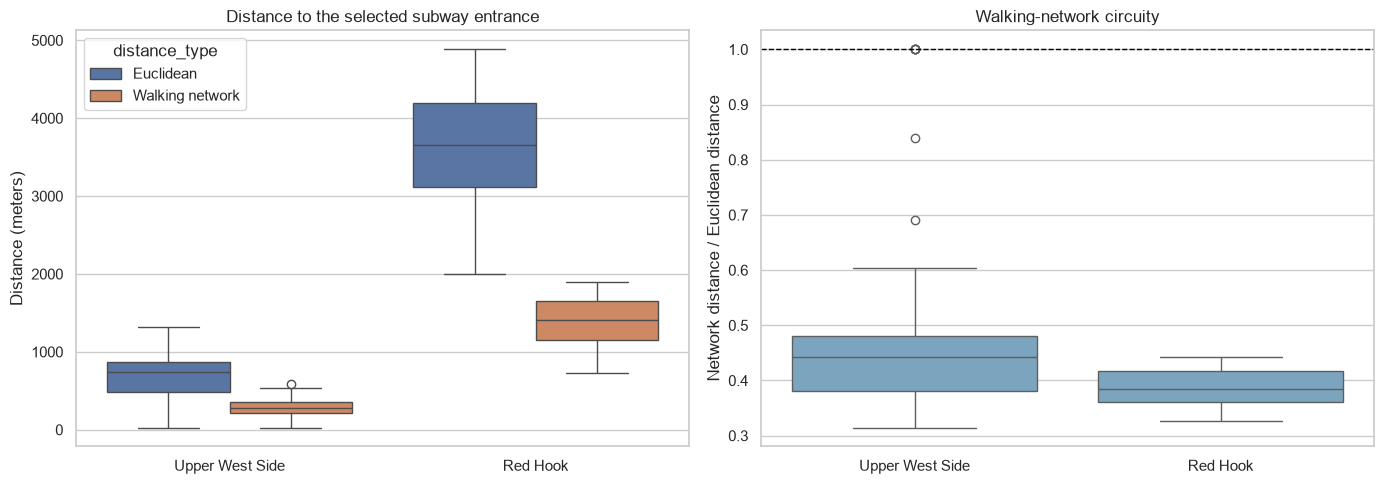

In [9]:
distance_long = results.melt(
    id_vars=["neighborhood", "origin_node"],
    value_vars=["euclidean_m", "network_m"],
    var_name="distance_type",
    value_name="distance_m",
)
distance_long["distance_type"] = distance_long["distance_type"].map({
    "euclidean_m": "Euclidean",
    "network_m": "Walking network",
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=distance_long,
    x="neighborhood",
    y="distance_m",
    hue="distance_type",
    ax=axes[0],
)
axes[0].set_title("Distance to the selected subway entrance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Distance (meters)")

sns.boxplot(
    data=results,
    x="neighborhood",
    y="circuity_ratio",
    color="#70a6c9",
    ax=axes[1],
)
axes[1].axhline(1, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Walking-network circuity")
axes[1].set_xlabel("")
axes[1].set_ylabel("Network distance / Euclidean distance")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distance_comparison.png", dpi=200, bbox_inches="tight")


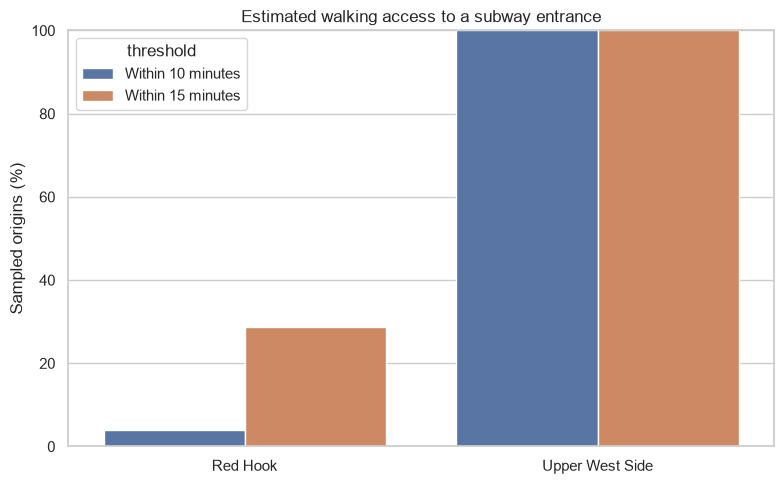

In [9]:
coverage = (
    results.assign(
        within_10_min=results["walking_min"] <= 10,
        within_15_min=results["walking_min"] <= 15,
    )
    .groupby("neighborhood")[["within_10_min", "within_15_min"]]
    .mean()
    .mul(100)
    .reset_index()
    .melt(
        id_vars="neighborhood",
        var_name="threshold",
        value_name="percent",
    )
)
coverage["threshold"] = coverage["threshold"].map({
    "within_10_min": "Within 10 minutes",
    "within_15_min": "Within 15 minutes",
})

plt.figure(figsize=(8, 5))
sns.barplot(
    data=coverage,
    x="neighborhood",
    y="percent",
    hue="threshold",
)
plt.ylim(0, 100)
plt.xlabel("")
plt.ylabel("Sampled origins (%)")
plt.title("Estimated walking access to a subway entrance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "walking_time_coverage.png", dpi=200, bbox_inches="tight")


## Accessibility maps


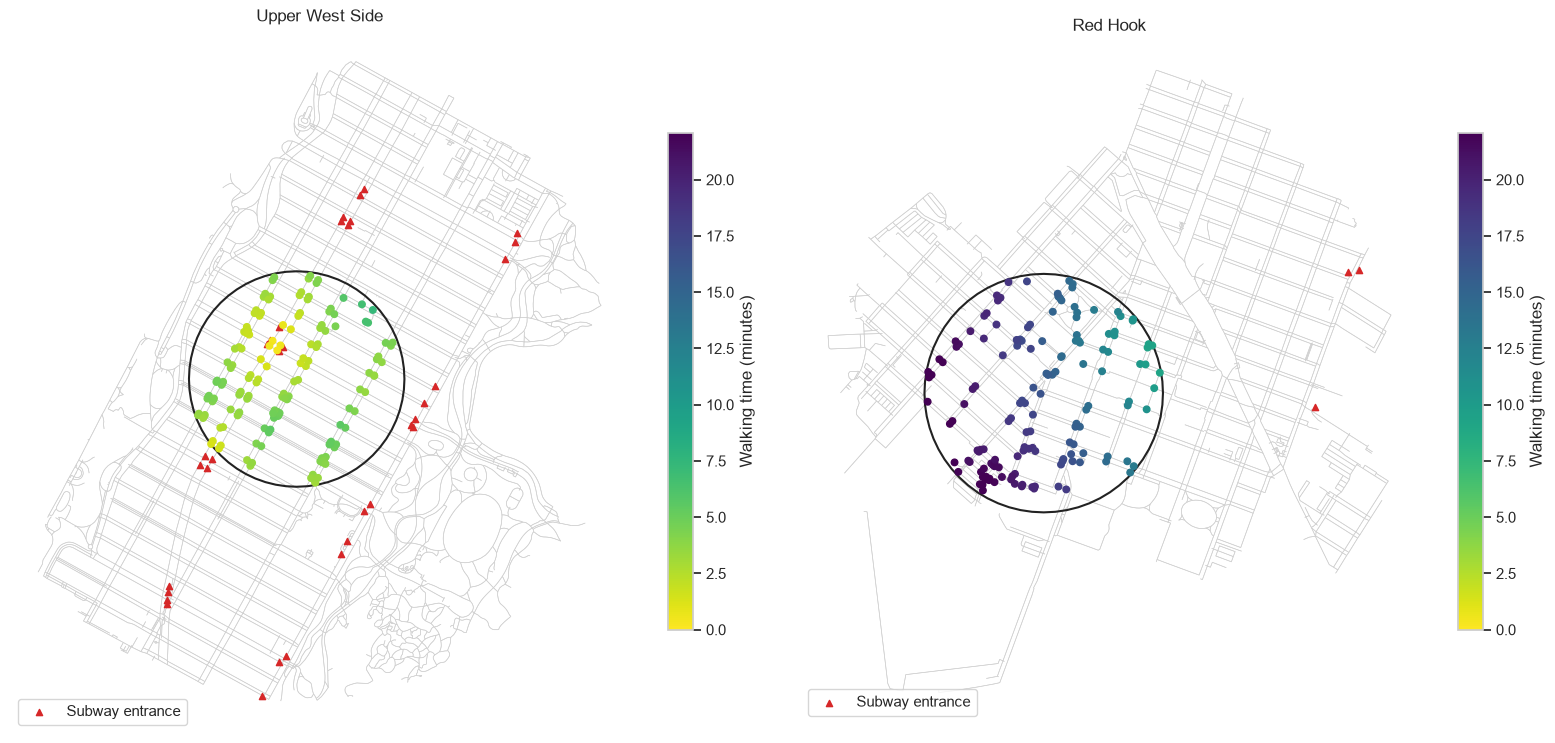

In [10]:
vmax = results["walking_min"].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, neighborhood in zip(axes, PLACES):
    graph = graphs[neighborhood]
    neighborhood_results, nearby_entrances, _ = analyses[neighborhood]
    edges = ox.convert.graph_to_gdfs(graph, nodes=False)

    edges.plot(ax=ax, color="#d0d0d0", linewidth=0.45, zorder=1)
    boundaries[neighborhood].boundary.plot(
        ax=ax, color="#222222", linewidth=1.5, zorder=2
    )
    nearby_entrances.plot(
        ax=ax, color="#d62728", marker="^", markersize=20, zorder=3, label="Subway entrance"
    )
    neighborhood_results.plot(
        ax=ax,
        column="walking_min",
        cmap="viridis_r",
        vmin=0,
        vmax=vmax,
        markersize=22,
        zorder=4,
        legend=True,
        legend_kwds={"label": "Walking time (minutes)", "shrink": 0.65},
    )

    ax.set_title(neighborhood)
    ax.set_axis_off()
    ax.legend(loc="lower left")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accessibility_maps.png", dpi=200, bbox_inches="tight")


## Example routes

For each neighborhood, this selects the origin closest to the neighborhood's median network distance. The dashed line is Euclidean distance to the same entrance used by the shortest walking route


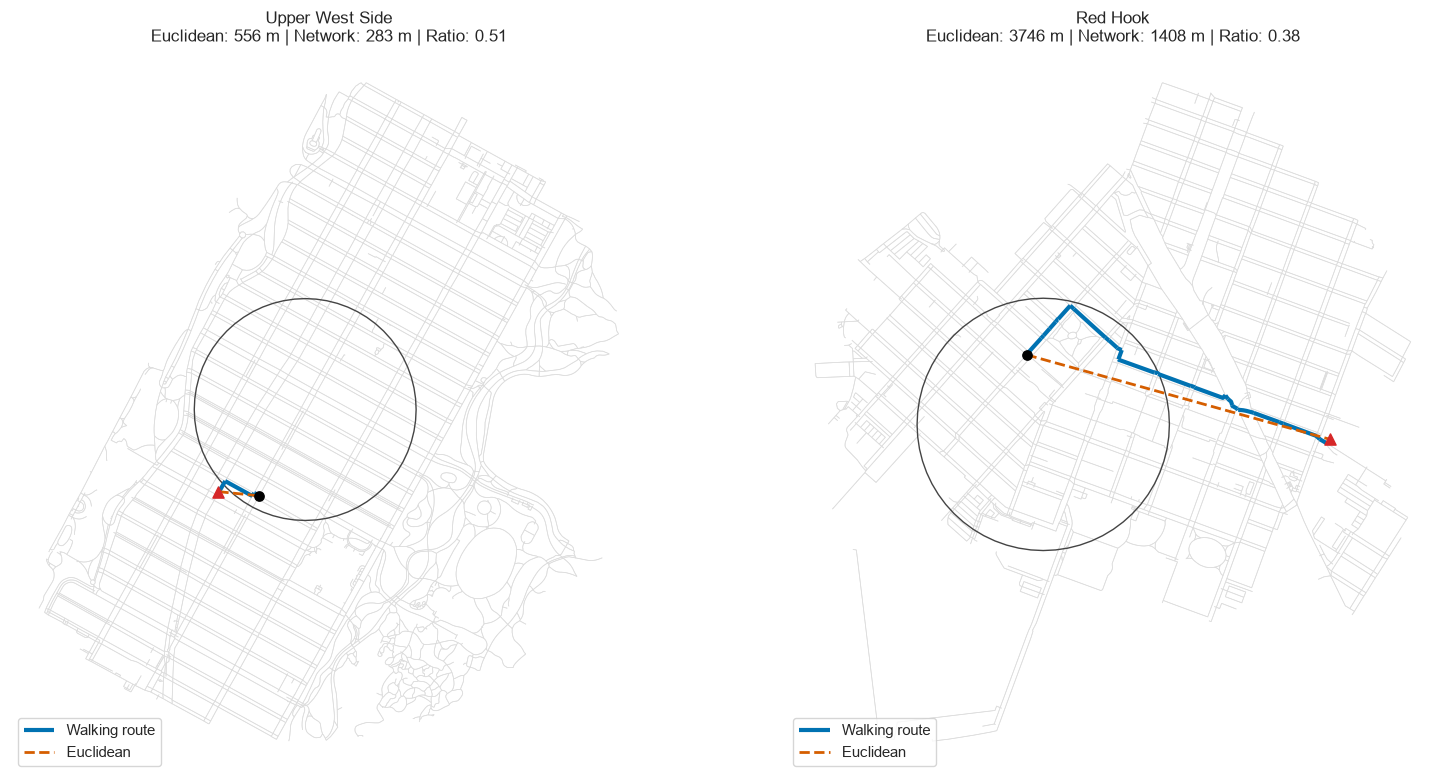

In [11]:
def route_to_linestring(graph, route):
    route_edges = ox.routing.route_to_gdf(graph, route, weight="length")
    return route_edges.geometry.union_all()


fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, neighborhood in zip(axes, PLACES):
    neighborhood_results, nearby_entrances, routes = analyses[neighborhood]
    median_distance = neighborhood_results["network_m"].median()
    example_idx = (
        neighborhood_results["network_m"] - median_distance
    ).abs().idxmin()
    example = neighborhood_results.loc[example_idx]
    route = routes[example["origin_node"]]

    edges = ox.convert.graph_to_gdfs(graphs[neighborhood], nodes=False)
    edges.plot(ax=ax, color="#dddddd", linewidth=0.5)
    boundaries[neighborhood].boundary.plot(ax=ax, color="#444444", linewidth=1)

    route_geom = route_to_linestring(graphs[neighborhood], route)
    gpd.GeoSeries([route_geom], crs=PROJECT_CRS).plot(
        ax=ax, color="#0072b2", linewidth=3, label="Walking route"
    )

    straight = LineString([
        example.geometry,
        example["destination_geometry"],
    ])
    gpd.GeoSeries([straight], crs=PROJECT_CRS).plot(
        ax=ax,
        color="#d55e00",
        linewidth=2,
        linestyle="--",
        label="Euclidean",
    )

    gpd.GeoSeries([example.geometry], crs=PROJECT_CRS).plot(
        ax=ax, color="black", markersize=45, zorder=5
    )
    gpd.GeoSeries([example["destination_geometry"]], crs=PROJECT_CRS).plot(
        ax=ax, color="#d62728", marker="^", markersize=65, zorder=5
    )

    ax.set_title(
        f"{neighborhood}\n"
        f"Euclidean: {example['euclidean_m']:.0f} m | "
        f"Network: {example['network_m']:.0f} m | "
        f"Ratio: {example['circuity_ratio']:.2f}"
    )
    ax.set_axis_off()
    ax.legend(loc="lower left")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "example_routes.png", dpi=200, bbox_inches="tight")


## Export results


In [12]:
results.drop(columns=["destination_geometry"]).to_file(
    OUTPUT_DIR / "origin_access_results.geojson",
    driver="GeoJSON",
)
summary.to_csv(OUTPUT_DIR / "summary_statistics.csv")

print("Saved outputs to:", OUTPUT_DIR.resolve())


Saved outputs to: /Users/ericliu/Documents/GitHub/cdp-mapping-systems/content/Assignments/Eric Liu Assignments/Assignment 3/outputs
